# Source Attestation & Trust Calibration — Analysis Notebook

Analysis pipeline for the 3×2×2 within-subjects vignette study (attestation × correctness × stakes).

Expected columns: `response_id, version, trial_position, stem_id, stakes, att_level, correctness, trust_num, reliance_code, consequence_num, att_code, corr_code, stakes_code`.

Coding convention (from the prep pipeline): `att_code` ∈ {0,1,2} (none/weak/strong, ordinal); `corr_code`, `stakes_code` ∈ {−0.5,+0.5} (contrast-coded).

## 0. Setup

In [52]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
from pathlib import Path
import matplot2tikz, os

os.makedirs("latex_figures", exist_ok=True)

def save_tikz(name):
    """Save the current figure as a .tex file for LaTeX."""
    try:
        matplot2tikz.clean_figure()
    except (ValueError, IndexError):
        pass  # cleaning is optional; skip when it chokes on this figure
    matplot2tikz.save(f"latex_figures/{name}.tex")

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:0.4f}')
pd.set_option('display.max_columns', None)

DATA_DIR = Path('../prepped_data')
DATA_FILE = "long_coded.csv"
DATA_PATH = DATA_DIR / DATA_FILE
assert DATA_PATH.exists(), f'Missing {DATA_PATH}'
IMG_DIR = Path('images')
ATT_ORDER = ['none', 'weak', 'strong']

## 1. Load & validate

In [53]:
df = pd.read_csv(DATA_PATH)

required = ['response_id', 'stem_id', 'stakes', 'att_level', 'correctness',
            'trust_num', 'reliance_code', 'consequence_num',
            'att_code', 'corr_code', 'stakes_code']
missing = [c for c in required if c not in df.columns]
assert not missing, f'Missing required columns: {missing}'

n_part = df['response_id'].nunique()
trials = df.groupby('response_id').size()
print(f'Participants: {n_part}')
print(f'Rows (participant-trials): {len(df)}')
print(f'Trials per participant — min {trials.min()}, median {int(trials.median())}, max {trials.max()}')
print(f'Unique stems: {df.stem_id.nunique()}')
if "version" in df.columns:
    print(f'Versions present: {sorted(df.version.unique())}')

# Coding sanity checks
print('\nCoding check:')
print('  att_code   :', sorted(df.att_code.dropna().unique()), '(expect 0,1,2)')
print('  corr_code  :', sorted(df.corr_code.dropna().unique()), '(expect -0.5,0.5)')
print('  stakes_code:', sorted(df.stakes_code.dropna().unique()), '(expect -0.5,0.5)')
print('  trust_num  :', df.trust_num.min(), 'to', df.trust_num.max(), '(expect 1-7)')
print('  reliance   :', sorted(df.reliance_code.dropna().unique()), '(expect 1,2,3)')
print('  consequence:', df.consequence_num.min(), 'to', df.consequence_num.max(), '(expect 1-5)')

Participants: 85
Rows (participant-trials): 1020
Trials per participant — min 12, median 12, max 12
Unique stems: 12
Versions present: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Coding check:
  att_code   : [np.int64(0), np.int64(1), np.int64(2)] (expect 0,1,2)
  corr_code  : [np.float64(-0.5), np.float64(0.5)] (expect -0.5,0.5)
  stakes_code: [np.float64(-0.5), np.float64(0.5)] (expect -0.5,0.5)
  trust_num  : 1 to 7 (expect 1-7)
  reliance   : [np.int64(1), np.int64(2), np.int64(3)] (expect 1,2,3)
  consequence: 1 to 5 (expect 1-5)


In [54]:
# Design balance: cell counts for the full 3x2x2 crossing
cell_counts = (df.groupby(['att_level', 'correctness', 'stakes'])
                 .size().rename('n').reset_index())
cell_pivot = cell_counts.pivot_table(index=['att_level'],
                                     columns=['correctness', 'stakes'],
                                     values='n').reindex(ATT_ORDER)
print('Cell counts (rows = attestation):')
display(cell_pivot)

# Missingness on outcomes
print('\nMissing values on outcomes:')
print(df[['trust_num', 'reliance_code', 'consequence_num']].isna().sum())

Cell counts (rows = attestation):


correctness correct         incorrect        
stakes         high     low      high     low
att_level                                    
none        85.0000 85.0000   85.0000 85.0000
weak        85.0000 85.0000   85.0000 85.0000
strong      85.0000 85.0000   85.0000 85.0000


Missing values on outcomes:
trust_num          0
reliance_code      0
consequence_num    0
dtype: int64


## 2. Descriptives by condition

In [55]:
def desc_by(col, by):
    g = df.groupby(by)[col].agg(['mean', 'std', 'count'])
    if by == 'att_level':
        g = g.reindex(ATT_ORDER)
    return g

print('=== TRUST (1-7) ===')
print('\nby attestation:'); display(desc_by('trust_num', 'att_level'))
print('by correctness:'); display(desc_by('trust_num', 'correctness'))
print('by stakes:'); display(desc_by('trust_num', 'stakes'))

print('\nTrust: attestation x correctness (means):')
display(df.pivot_table('trust_num', 'att_level', 'correctness', 'mean').reindex(ATT_ORDER))

=== TRUST (1-7) ===

by attestation:


,mean,std,count
att_level,,,
none,3.8529,1.7112,340
weak,4.3500,1.5432,340
strong,4.6559,1.6552,340


by correctness:


,mean,std,count
correctness,,,
correct,4.3549,1.6789,510
incorrect,4.2176,1.6590,510


by stakes:


,mean,std,count
stakes,,,
high,4.0902,1.6536,510
low,4.4824,1.6640,510



Trust: attestation x correctness (means):


correctness,correct,incorrect
att_level,,
none,4.0000,3.7059
weak,4.2941,4.4059
strong,4.7706,4.5412


In [56]:
print('=== RELIANCE (1=Reject, 2=Verify, 3=Use) ===')
print('by attestation:'); display(desc_by('reliance_code', 'att_level'))
print('by correctness:'); display(desc_by('reliance_code', 'correctness'))
print('by stakes:'); display(desc_by('reliance_code', 'stakes'))

print('\n=== PERCEIVED CONSEQUENCE (1-5) ===')
print('by stakes (manipulation check):'); display(desc_by('consequence_num', 'stakes'))
print('by attestation:'); display(desc_by('consequence_num', 'att_level'))

=== RELIANCE (1=Reject, 2=Verify, 3=Use) ===
by attestation:


,mean,std,count
att_level,,,
none,2.0294,0.5792,340
weak,2.1294,0.4867,340
strong,2.2265,0.5082,340


by correctness:


,mean,std,count
correctness,,,
correct,2.1392,0.5075,510
incorrect,2.1176,0.5553,510


by stakes:


,mean,std,count
stakes,,,
high,2.0078,0.4606,510
low,2.2490,0.5700,510



=== PERCEIVED CONSEQUENCE (1-5) ===
by stakes (manipulation check):


,mean,std,count
stakes,,,
high,3.9588,0.9672,510
low,2.4725,1.1853,510


by attestation:


,mean,std,count
att_level,,,
none,3.1765,1.3430,340
weak,3.2765,1.2714,340
strong,3.1941,1.3228,340


## 3. Mixed models — crossed random effects (participant + stem)

- **H1**: positive `att_code` slope on trust and reliance.
- **H2**: `att_code` effect persists controlling for `corr_code`; small/null `corr_code` effect = trust tracks the label, not truth.
- **H4**: `stakes_code` effect, and the attestation×stakes / correctness×stakes interactions.

In [57]:
def fit_crossed(dv, data, extra_fixed=''):
    """Crossed RE: random intercept for participant + variance component for stem."""
    formula = f'{dv} ~ att_code + corr_code + stakes_code' + extra_fixed
    md = smf.mixedlm(formula, data, groups=data['response_id'],
                     re_formula='~1',
                     vc_formula={'stem': '0 + C(stem_id)'})
    return md.fit(reml=False)

print('============ TRUST — main-effects model ============')
m_trust = fit_crossed('trust_num', df)
print(m_trust.summary())

============ TRUST — main-effects model ============
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: trust_num 
No. Observations: 1020    Method:             ML        
No. Groups:       85      Scale:              0.8744    
Min. group size:  12      Log-Likelihood:     -1813.0385
Max. group size:  12      Converged:          Yes       
Mean group size:  12.0                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      3.885    0.122 31.931 0.000  3.646  4.123
att_code       0.401    0.051  7.941 0.000  0.302  0.501
corr_code      0.137    0.083  1.663 0.096 -0.025  0.299
stakes_code   -0.392    0.083 -4.750 0.000 -0.554 -0.230
Group Var      0.896                                    
stem Var       0.864                                    



In [58]:
print('============ RELIANCE — main-effects model ============')
print('(Reliance is ordinal 1-3; this LMM treats it as continuous for a fast read.')
print(' See Section 3b for the ordinal model.)')
m_rel = fit_crossed('reliance_code', df)
print(m_rel.summary())

print('\n============ PERCEIVED CONSEQUENCE — manipulation check ============')
m_cons = fit_crossed('consequence_num', df)
print(m_cons.summary())

============ RELIANCE — main-effects model ============
(Reliance is ordinal 1-3; this LMM treats it as continuous for a fast read.
 See Section 3b for the ordinal model.)
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: reliance_code
No. Observations: 1020    Method:             ML           
No. Groups:       85      Scale:              0.0933       
Min. group size:  12      Log-Likelihood:     -751.4265    
Max. group size:  12      Converged:          Yes          
Mean group size:  12.0                                     
------------------------------------------------------------
             Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
------------------------------------------------------------
Intercept     2.030     0.029  70.445  0.000   1.973   2.086
att_code      0.099     0.019   5.233  0.000   0.062   0.135
corr_code     0.022     0.031   0.702  0.483  -0.039   0.082
stakes_code  -0.241     0.031  -7.845  0.000  -0.301 

### 3a. H4 — interaction & stakes moderation

In [59]:
print('=== Trust: attestation x correctness (H4 core interaction) ===')
m_int = fit_crossed('trust_num', df, extra_fixed=' + att_code:corr_code')
print(m_int.summary().tables[1])

print('\n=== Trust: full stakes moderation (att x corr x stakes) ===')
m_full = smf.mixedlm('trust_num ~ att_code * corr_code * stakes_code',
                     df, groups=df['response_id'], re_formula='~1',
                     vc_formula={'stem': '0 + C(stem_id)'}).fit(reml=False)
print(m_full.summary().tables[1])

=== Trust: attestation x correctness (H4 core interaction) ===
                     Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept            3.885    0.122  31.931  0.000   3.646   4.123
att_code             0.401    0.051   7.942  0.000   0.302   0.501
corr_code            0.170    0.131   1.299  0.194  -0.086   0.425
stakes_code         -0.392    0.083  -4.750  0.000  -0.554  -0.230
att_code:corr_code  -0.032    0.101  -0.320  0.749  -0.231   0.166
Group Var            0.896                                        
stem Var             0.864                                        

=== Trust: full stakes moderation (att x corr x stakes) ===
                                 Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                        3.885    0.122  31.968  0.000   3.647   4.123
att_code                         0.401    0.050   7.996  0.000   0.303   0.500
corr_code                        0.170    0.130   1.308  0.191  -0.084   0.424
att_code:corr_code      

### 3b. Reliance as ordinal (robustness)

In [60]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

ord_df = df.dropna(subset=['reliance_code', 'att_code', 'corr_code', 'stakes_code']).copy()
ord_df['reliance_ord'] = ord_df['reliance_code'].astype(int)

om = OrderedModel(ord_df['reliance_ord'],
                  ord_df[['att_code', 'corr_code', 'stakes_code']],
                  distr='logit')
om_res = om.fit(method='bfgs', disp=False)
print('=== Ordinal logit (no RE) — reliance ===')
print(om_res.summary())

# GEE clustered by participant (population-averaged, accounts for within-person dependence)
print('\n=== GEE (clustered by participant) — reliance ===')
gee = smf.gee('reliance_code ~ att_code + corr_code + stakes_code',
              groups='response_id', data=ord_df,
              cov_struct=sm.cov_struct.Exchangeable()).fit()
print(gee.summary().tables[1])

=== Ordinal logit (no RE) — reliance ===
                             OrderedModel Results                             
Dep. Variable:           reliance_ord   Log-Likelihood:                -764.24
Model:                   OrderedModel   AIC:                             1538.
Method:            Maximum Likelihood   BIC:                             1563.
Date:                Fri, 10 Jul 2026                                         
Time:                        23:50:18                                         
No. Observations:                1020                                         
Df Residuals:                    1015                                         
Df Model:                           3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
att_code        0.4092      0.086      4.771      0.000       0.241       0.577
corr_cod

## 4. H3 — mediation scaffold (attestation/correctness → trust → reliance)

In [61]:
# Path a: effect of att/corr on the mediator (trust) — already in m_trust
print('PATH a (predictors -> trust):')
print(m_trust.summary().tables[1].loc[['att_code', 'corr_code']])

# Path b & c': mediator + predictors -> reliance
print('\nPATH b/c\' (trust + predictors -> reliance):')
m_med = smf.mixedlm('reliance_code ~ trust_num + att_code + corr_code + stakes_code',
                    df, groups=df['response_id'], re_formula='~1',
                    vc_formula={'stem': '0 + C(stem_id)'}).fit(reml=False)
print(m_med.summary().tables[1])

print('\n# To complete H3: compute indirect effect (a*b) with a bootstrap CI,')
print('# or use a multilevel mediation framework. This cell only exposes the paths.')

PATH a (predictors -> trust):
           Coef. Std.Err.      z  P>|z|  [0.025 0.975]
att_code   0.401    0.051  7.941  0.000   0.302  0.501
corr_code  0.137    0.083  1.663  0.096  -0.025  0.299

PATH b/c' (trust + predictors -> reliance):
              Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept     1.254    0.041  30.766  0.000   1.174   1.334
trust_num     0.200    0.009  23.281  0.000   0.183   0.216
att_code      0.018    0.016   1.179  0.238  -0.012   0.049
corr_code    -0.006    0.025  -0.235  0.814  -0.055   0.043
stakes_code  -0.163    0.025  -6.506  0.000  -0.212  -0.114
Group Var     0.014                                        
stem Var      0.096                                        

# To complete H3: compute indirect effect (a*b) with a bootstrap CI,
# or use a multilevel mediation framework. This cell only exposes the paths.


## 5. Tidy results export

In [62]:
def tidy(res, label):
    """Pull the coefficient table from a fitted mixedlm result into a tidy frame."""
    p = pd.DataFrame({
        'term': res.params.index,
        'coef': res.params.values,
        'std_err': res.bse.reindex(res.params.index).values,
        'z': res.tvalues.reindex(res.params.index).values,
        'p_value': res.pvalues.reindex(res.params.index).values,
    })
    p.insert(0, 'model', label)
    return p

results = pd.concat([
    tidy(m_trust, 'trust_main'),
    tidy(m_rel,   'reliance_main_LMM'),
    tidy(m_cons,  'consequence_main'),
    tidy(m_int,   'trust_attXcorr'),
], ignore_index=True)

display(results)
results.to_csv('analysis_results.csv', index=False)
print('Wrote analysis_results.csv')

,model,term,coef,std_err,z,p_value
0,trust_main,Intercept,3.8848,0.1217,31.9307,0.0000
1,trust_main,att_code,0.4015,0.0506,7.9411,0.0000
2,trust_main,corr_code,0.1373,0.0826,1.6625,0.0964
3,trust_main,stakes_code,-0.3922,0.0826,-4.7501,0.0000
4,trust_main,Group Var,1.0248,NaN,NaN,NaN
5,trust_main,stem Var,0.9877,NaN,NaN,NaN
6,reliance_main_LMM,Intercept,2.0299,0.0288,70.4446,0.0000
7,reliance_main_LMM,att_code,0.0985,0.0188,5.2334,0.0000
8,reliance_main_LMM,corr_code,0.0216,0.0307,0.7015,0.4830
9,reliance_main_LMM,stakes_code,-0.2412,0.0307,-7.8446,0.0000


Wrote analysis_results.csv


## 6. Quick diagnostic plots

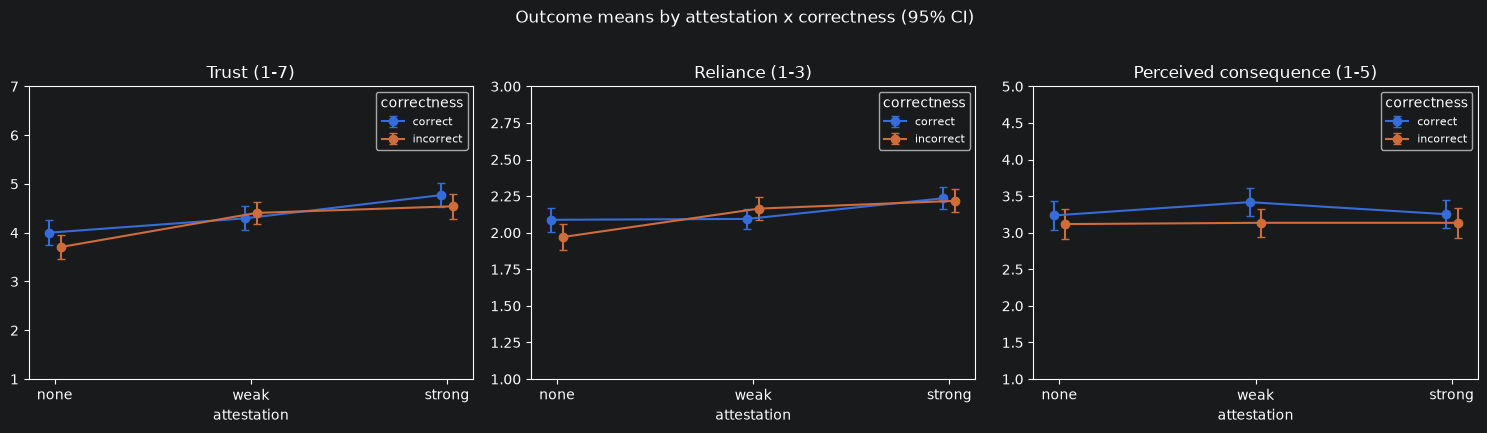

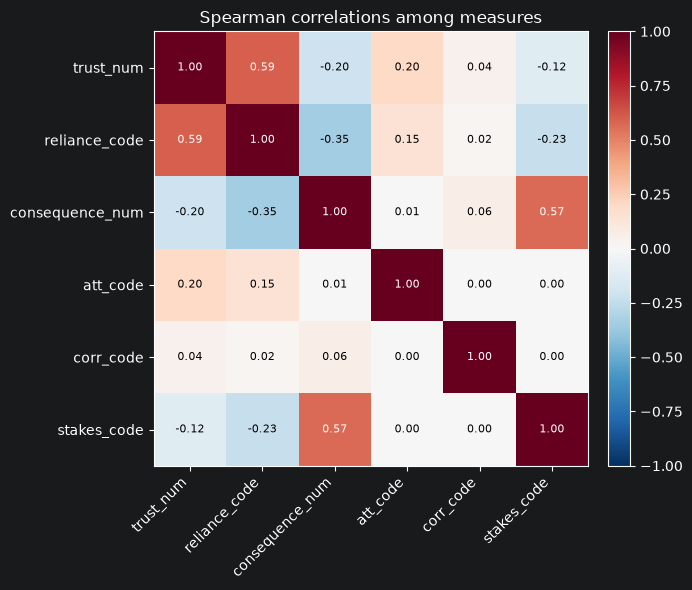

Note: att/corr/stakes are coded predictors, so their mutual
correlations are ~0 by design (balanced factorial).


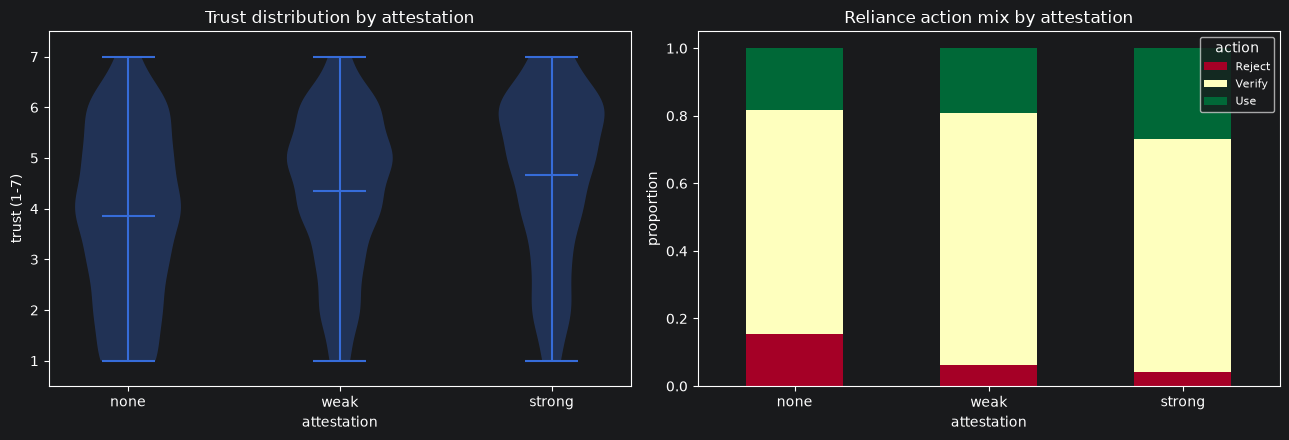

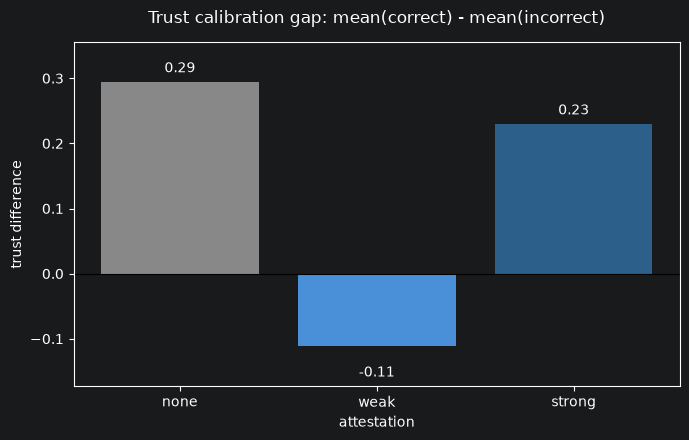

In [63]:
import matplotlib.pyplot as plt
import numpy as np

def _ci95(s):
    s = s.dropna()
    if len(s) < 2:
        return np.nan
    return 1.96 * s.std(ddof=1) / np.sqrt(len(s))

# --- Figure 1: outcome means by attestation x correctness, with 95% CIs ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
panels = [('trust_num', 'Trust (1-7)', (1, 7)),
          ('reliance_code', 'Reliance (1-3)', (1, 3)),
          ('consequence_num', 'Perceived consequence (1-5)', (1, 5))]
for ax, (dv, lab, ylim) in zip(axes, panels):
    m = df.pivot_table(dv, 'att_level', 'correctness', 'mean').reindex(ATT_ORDER)
    e = df.pivot_table(dv, 'att_level', 'correctness', _ci95).reindex(ATT_ORDER)
    x = np.arange(len(ATT_ORDER))
    for j, col in enumerate(m.columns):
        ax.errorbar(x + (j - 0.5) * 0.06, m[col], yerr=e[col],
                    marker='o', capsize=3, label=col)
    ax.set_xticks(x); ax.set_xticklabels(ATT_ORDER)
    ax.set_title(lab); ax.set_xlabel('attestation'); ax.set_ylim(ylim)
    ax.legend(title='correctness', fontsize=8)
fig.suptitle('Outcome means by attestation x correctness (95% CI)', y=1.02)
plt.tight_layout()
fig_name = 'outcome_means_by_attestation'
plt.savefig(IMG_DIR/f'{fig_name}.png', dpi=130, bbox_inches='tight')
save_tikz(fig_name)
plt.show()

# --- Figure 2: Spearman correlation heatmap of numeric measures ---
num = ['trust_num', 'reliance_code', 'consequence_num',
       'att_code', 'corr_code', 'stakes_code']
corr = df[num].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(num))); ax.set_xticklabels(num, rotation=45, ha='right')
ax.set_yticks(range(len(num))); ax.set_yticklabels(num)
for i in range(len(num)):
    for j in range(len(num)):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if abs(v) > 0.5 else 'black', fontsize=8)
plt.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title('Spearman correlations among measures')
plt.tight_layout()
fig_name = 'spearman_corr_heatmap'
plt.savefig(IMG_DIR/f'{fig_name}.png', dpi=130, bbox_inches='tight')
save_tikz(fig_name)
plt.show()
print('Note: att/corr/stakes are coded predictors, so their mutual')
print('correlations are ~0 by design (balanced factorial).')

# --- Figure 3: trust distribution + reliance action mix by attestation ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

data = [df[df.att_level == a].trust_num.dropna().values for a in ATT_ORDER]
axes[0].violinplot(data, showmeans=True)
axes[0].set_xticks([1, 2, 3]); axes[0].set_xticklabels(ATT_ORDER)
axes[0].set_title('Trust distribution by attestation')
axes[0].set_ylabel('trust (1-7)'); axes[0].set_ylim(0.5, 7.5)
axes[0].set_xlabel('attestation')

prop = (df.groupby('att_level')['reliance_code']
          .value_counts(normalize=True).unstack().reindex(ATT_ORDER))
prop.columns = ['Reject', 'Verify', 'Use'][:prop.shape[1]]
prop.plot(kind='bar', stacked=True, ax=axes[1], colormap='RdYlGn')
axes[1].set_title('Reliance action mix by attestation')
axes[1].set_ylabel('proportion'); axes[1].set_xlabel('attestation')
axes[1].legend(title='action', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
fig_name = 'dist_reliance_action'
plt.savefig(IMG_DIR/f'{fig_name}.png', dpi=130, bbox_inches='tight')
save_tikz(fig_name)
plt.show()

# --- Figure 4: trust calibration gap = mean(correct) - mean(incorrect) ---
# A large positive gap = trust discriminates correct from incorrect (good
# calibration). A gap near zero = trust does NOT track truth at that
# attestation level (the miscalibration the study is about).
fig, ax = plt.subplots(figsize=(7, 4.5))
gap = df.pivot_table('trust_num', 'att_level', 'correctness', 'mean').reindex(ATT_ORDER)
diff = gap['correct'] - gap['incorrect']
ax.bar(ATT_ORDER, diff, color=['#888888', '#4a90d9', '#2c5f8a'])
ax.axhline(0, color='k', lw=0.8)
ax.set_title('Trust calibration gap: mean(correct) - mean(incorrect)', pad=14)
ax.set_ylabel('trust difference'); ax.set_xlabel('attestation')
ax.margins(y=0.15)
for i, v in enumerate(diff):
    ax.text(i, v + (0.01 if v >= 0 else -0.03), f'{v:.2f}',
            ha='center', va='bottom' if v >= 0 else 'top')
plt.tight_layout()
fig_name = 'calibration_gap'
plt.savefig(IMG_DIR/f'{fig_name}.png', dpi=130, bbox_inches='tight')
save_tikz(fig_name)
plt.show()

## 8. Intake & demographic figures

These require the per-participant intake columns produced by the updated `reconstruct_data.py` (`ai_expertise_num`, `baseline_trust_num`, `ai_frequency_num`, `age`, `gender`). If those columns aren't present, the cell prints a note and skips. **Expertise/baseline relationships are exploratory and underpowered at pilot N; demographics are for sample characterization only.**

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Map text intake scales to ordered ints if only the text versions are present.
_EXP = {'Novice':1,'Basic User':2,'Experienced User':3,'Advanced Practitioner':4,'Expert/Specialist':5}
_BT  = {'Strongly Distrust':1,'Distrust':2,'Neither Trust nor Distrust':3,'Trust':4,'Strongly Trust':5}
_FQ  = {'Never':0,'Monthly':1,'Weekly':2,'Daily':3}
if 'ai_expertise' in df.columns and 'ai_expertise_num' not in df.columns:
    df['ai_expertise_num'] = df['ai_expertise'].map(_EXP)
if 'baseline_trust' in df.columns and 'baseline_trust_num' not in df.columns:
    df['baseline_trust_num'] = df['baseline_trust'].map(_BT)
if 'ai_frequency' in df.columns and 'ai_frequency_num' not in df.columns:
    df['ai_frequency_num'] = df['ai_frequency'].map(_FQ)

HAS_INTAKE = any(c in df.columns for c in ['ai_expertise_num','baseline_trust_num'])
if not HAS_INTAKE:
    print('Intake columns not found. Run the updated reconstruct_data.py to merge')
    print('demographics, then re-load df. Skipping Section 8 figures.')
else:
    per_p = df.drop_duplicates('response_id').copy()
    print('Intake columns present; per-participant n =', len(per_p))

Intake columns present; per-participant n = 85


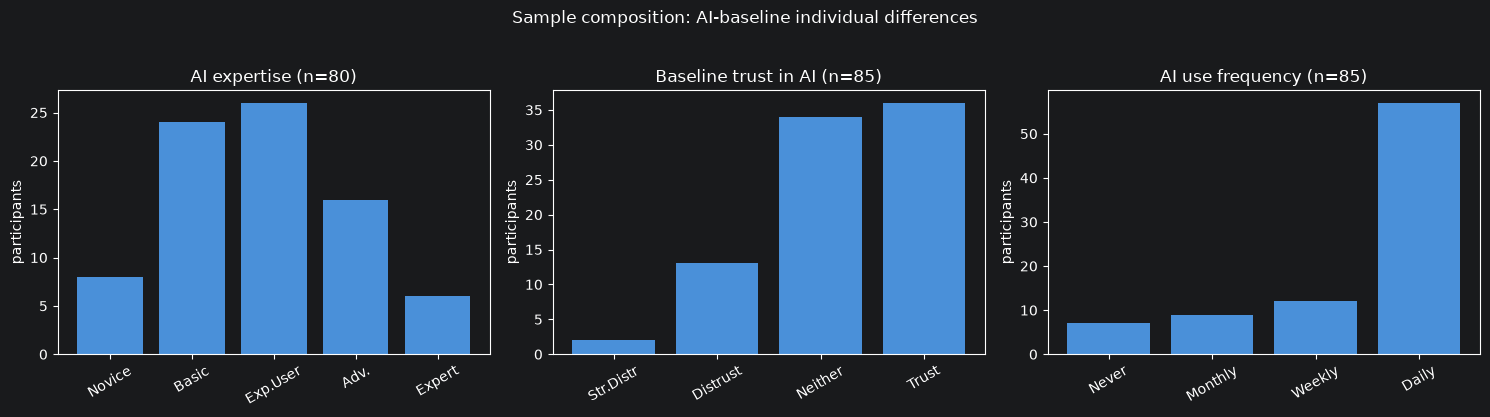

In [65]:
# --- Figure 5: AI-baseline individual differences (sample composition) ---
if HAS_INTAKE:
    specs = [('ai_expertise_num', 'AI expertise', {1:'Novice',2:'Basic',3:'Exp.User',4:'Adv.',5:'Expert'}),
             ('baseline_trust_num', 'Baseline trust in AI', {1:'Str.Distr',2:'Distrust',3:'Neither',4:'Trust',5:'Str.Trust'}),
             ('ai_frequency_num', 'AI use frequency', {0:'Never',1:'Monthly',2:'Weekly',3:'Daily'})]
    specs = [s for s in specs if s[0] in per_p.columns and per_p[s[0]].notna().any()]
    if specs:
        fig, axes = plt.subplots(1, len(specs), figsize=(5*len(specs), 4), squeeze=False)
        for ax, (col, lab, labels) in zip(axes[0], specs):
            vc = per_p[col].dropna().astype(int).value_counts().sort_index()
            ax.bar([labels.get(i, i) for i in vc.index], vc.values, color='#4a90d9')
            ax.set_title(f'{lab} (n={int(per_p[col].notna().sum())})')
            ax.set_ylabel('participants'); ax.tick_params(axis='x', rotation=30)
        fig.suptitle('Sample composition: AI-baseline individual differences', y=1.03)
        plt.tight_layout()
        fig_name = 'sample_composition_ai_baseline'
        plt.savefig(IMG_DIR/f'{fig_name}.png', dpi=130, bbox_inches='tight')
        save_tikz(fig_name)
        plt.show()

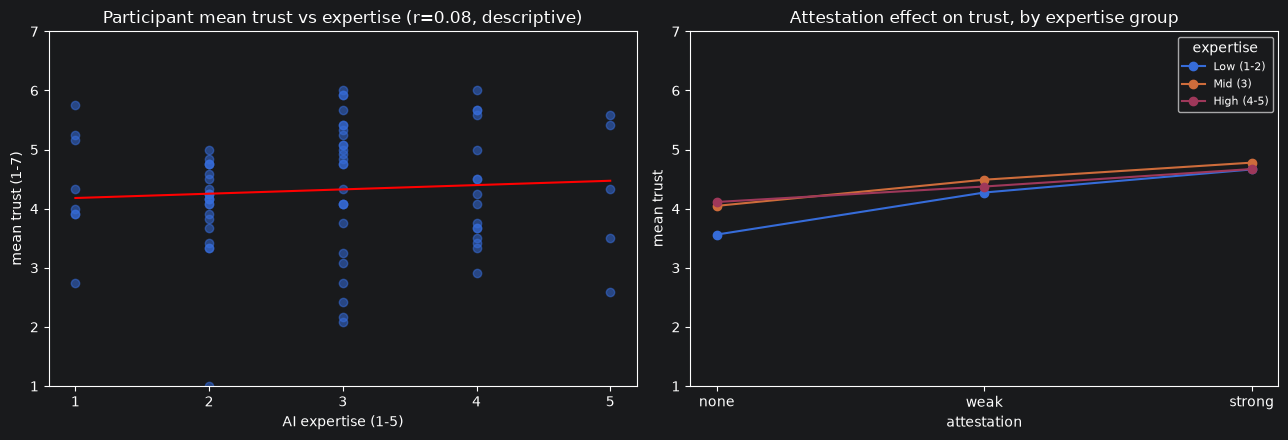

Right panel is descriptive; the att x expertise interaction test is in
the expertise model (Section 0-4 script / covariate models), and it is
underpowered at pilot N. Do not read a slope difference here as a finding.


In [66]:
# --- Figure 6: expertise vs trust, and attestation slope by expertise group ---
if HAS_INTAKE and 'ai_expertise_num' in df.columns and df['ai_expertise_num'].notna().any():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    pp = (df.dropna(subset=['ai_expertise_num'])
            .groupby('response_id')
            .agg(mt=('trust_num', 'mean'), exp=('ai_expertise_num', 'first')))
    axes[0].scatter(pp.exp, pp.mt, alpha=0.55)
    if pp.exp.nunique() > 1:
        b, a = np.polyfit(pp.exp, pp.mt, 1)
        xs = np.linspace(pp.exp.min(), pp.exp.max(), 50)
        axes[0].plot(xs, a + b*xs, 'r-', lw=1.5)
        r = pp.exp.corr(pp.mt)
        axes[0].set_title(f'Participant mean trust vs expertise (r={r:.2f}, descriptive)')
    axes[0].set_xlabel('AI expertise (1-5)'); axes[0].set_ylabel('mean trust (1-7)')
    axes[0].set_xticks([1,2,3,4,5]); axes[0].set_ylim(1, 7)

    d = df.dropna(subset=['ai_expertise_num']).copy()
    d['exp_grp'] = pd.cut(d.ai_expertise_num, [0,2,3,5], labels=['Low (1-2)','Mid (3)','High (4-5)'])
    for g in ['Low (1-2)','Mid (3)','High (4-5)']:
        m = d[d.exp_grp==g].groupby('att_level')['trust_num'].mean().reindex(ATT_ORDER)
        axes[1].plot(range(3), m.values, marker='o', label=g)
    axes[1].set_xticks(range(3)); axes[1].set_xticklabels(ATT_ORDER)
    axes[1].set_title('Attestation effect on trust, by expertise group')
    axes[1].set_xlabel('attestation'); axes[1].set_ylabel('mean trust'); axes[1].set_ylim(1, 7)
    axes[1].legend(title='expertise', fontsize=8)
    plt.tight_layout()
    fig_name = 'attenuation_by_expertise'
    plt.savefig(IMG_DIR/f'{fig_name}.png', dpi=130, bbox_inches='tight')
    save_tikz(fig_name)
    plt.show()
    print('Right panel is descriptive; the att x expertise interaction test is in')
    print('the expertise model (Section 0-4 script / covariate models), and it is')
    print('underpowered at pilot N. Do not read a slope difference here as a finding.')

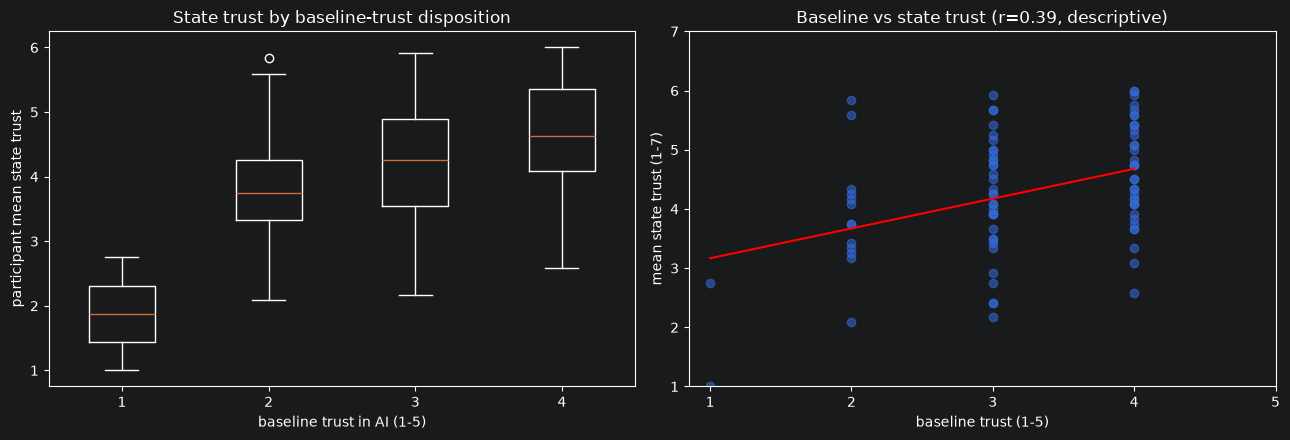

In [67]:
# --- Figure 7: baseline trust disposition vs state trust ---
if HAS_INTAKE and 'baseline_trust_num' in df.columns and df['baseline_trust_num'].notna().any():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    pp2 = (df.dropna(subset=['baseline_trust_num'])
             .groupby('response_id')
             .agg(mt=('trust_num', 'mean'), bt=('baseline_trust_num', 'first')))
    levels = sorted(pp2.bt.unique())
    axes[0].boxplot([pp2[pp2.bt==L].mt.values for L in levels],
                    tick_labels=[int(L) for L in levels])
    axes[0].set_title('State trust by baseline-trust disposition')
    axes[0].set_xlabel('baseline trust in AI (1-5)')
    axes[0].set_ylabel('participant mean state trust')

    axes[1].scatter(pp2.bt, pp2.mt, alpha=0.55)
    if pp2.bt.nunique() > 1:
        b, a = np.polyfit(pp2.bt, pp2.mt, 1)
        xs = np.linspace(pp2.bt.min(), pp2.bt.max(), 50)
        axes[1].plot(xs, a + b*xs, 'r-', lw=1.5)
        r = pp2.bt.corr(pp2.mt)
        axes[1].set_title(f'Baseline vs state trust (r={r:.2f}, descriptive)')
    axes[1].set_xlabel('baseline trust (1-5)'); axes[1].set_ylabel('mean state trust (1-7)')
    axes[1].set_xticks([1,2,3,4,5]); axes[1].set_ylim(1, 7)
    plt.tight_layout()
    fig_name = 'baseline_trust_vs_state_trust'
    plt.savefig(IMG_DIR/f'{fig_name}.png', dpi=130, bbox_inches='tight')
    save_tikz(fig_name)
    plt.show()

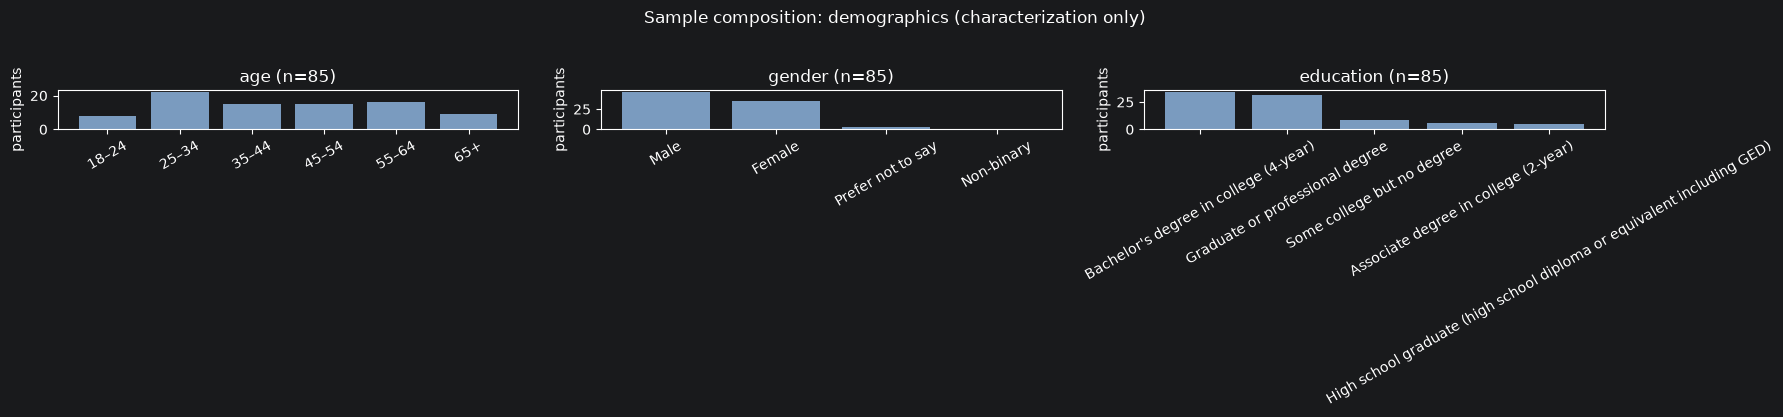

In [68]:
# --- Figure 8: demographic composition (characterization only) ---
if HAS_INTAKE:
    demo = [('age', ['18–24','25–34','35–44','45–54','55–64','65+']),
            ('gender', None),
            ('education', None)]
    demo = [(c, o) for c, o in demo if c in per_p.columns and per_p[c].notna().any()]
    if demo:
        fig, axes = plt.subplots(1, len(demo), figsize=(6*len(demo), 4), squeeze=False)
        for ax, (col, order) in zip(axes[0], demo):
            vc = per_p[col].value_counts()
            if order:
                vc = vc.reindex([o for o in order if o in vc.index])
            ax.bar(vc.index.astype(str), vc.values, color='#7a9bbf')
            ax.set_title(f'{col} (n={int(per_p[col].notna().sum())})')
            ax.set_ylabel('participants'); ax.tick_params(axis='x', rotation=30)
        fig.suptitle('Sample composition: demographics (characterization only)', y=1.03)
        plt.tight_layout()
        fig_name = 'sample_composition_demographics'
        plt.savefig(IMG_DIR/f'{fig_name}.png', dpi=130, bbox_inches='tight')
        save_tikz(fig_name)
        plt.show()